In [ ]:
############# Data Preprocessing #############
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, LabelEncoder

In [3]:
#Loading the dataset
data = pd.read_csv('C:\\Users\\srush\\OneDrive\\Desktop\\AIML Internship\\AIML-Internship\\Day 13_Regression Modules\\housing.csv')
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
### first 5 rows of the dataset
data.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
### Checking for null values ###
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [ ]:
#### Handling Missing Values ####
data["total_bedrooms"] = data["total_bedrooms"].fillna(data["total_bedrooms"].mean())

In [ ]:
#### Checking for null values after handling missing values #### 
data.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [ ]:
#### Removing Duplicates ####
data.drop_duplicates(inplace=True)
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1


In [ ]:
##### Converting Categorical Variables ####
label_encoder = LabelEncoder()
data['ocean_proximity'] = label_encoder.fit_transform(data['ocean_proximity'])
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1


In [14]:
### Removing Outliers
Q1 = data['median_house_value'].quantile(0.25)
Q3 = data['median_house_value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data = data[(data['median_house_value'] >= lower_bound) & (data['median_house_value'] <= upper_bound)]
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1


In [25]:
########## Feature Scaling #########
scaler = StandardScaler()

data_scaled = scaler.fit_transform(data)

data_scaled = pd.DataFrame(data_scaled, columns=data.columns)

data_scaled.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-1.329808,1.034817,1.011986,-0.796925,-0.977215,-0.978870,-0.979155,2.990995,2.742648,1.326825
1,-1.324823,1.025518,-0.588340,2.051432,1.346353,0.836879,1.660479,2.975718,1.756648,1.326825
2,-1.334794,1.020869,1.892166,-0.528074,-0.832140,-0.826903,-0.846130,2.305580,1.689588,1.326825
3,-1.339780,1.020869,1.892166,-0.616470,-0.725118,-0.772754,-0.736580,1.269368,1.576423,1.326825
4,-1.339780,1.020869,1.892166,-0.454792,-0.618096,-0.766640,-0.632247,0.115947,1.585853,1.326825


In [ ]:
### Splitting the data into features and target variable
X = data_scaled.drop('median_house_value', axis=1)  
y = data_scaled['median_house_value']
data_scaled.columns
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [29]:
print(X.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -1.329808  1.034817            1.011986    -0.796925       -0.977215   
1  -1.324823  1.025518           -0.588340     2.051432        1.346353   
2  -1.334794  1.020869            1.892166    -0.528074       -0.832140   
3  -1.339780  1.020869            1.892166    -0.616470       -0.725118   
4  -1.339780  1.020869            1.892166    -0.454792       -0.618096   

   population  households  median_income  ocean_proximity  
0   -0.978870   -0.979155       2.990995         1.326825  
1    0.836879    1.660479       2.975718         1.326825  
2   -0.826903   -0.846130       2.305580         1.326825  
3   -0.772754   -0.736580       1.269368         1.326825  
4   -0.766640   -0.632247       0.115947         1.326825  


In [31]:
print(y.head())

0    2.742648
1    1.756648
2    1.689588
3    1.576423
4    1.585853
Name: median_house_value, dtype: float64


In [32]:
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)       

Training set shape: (15655, 9)
Testing set shape: (3914, 9)


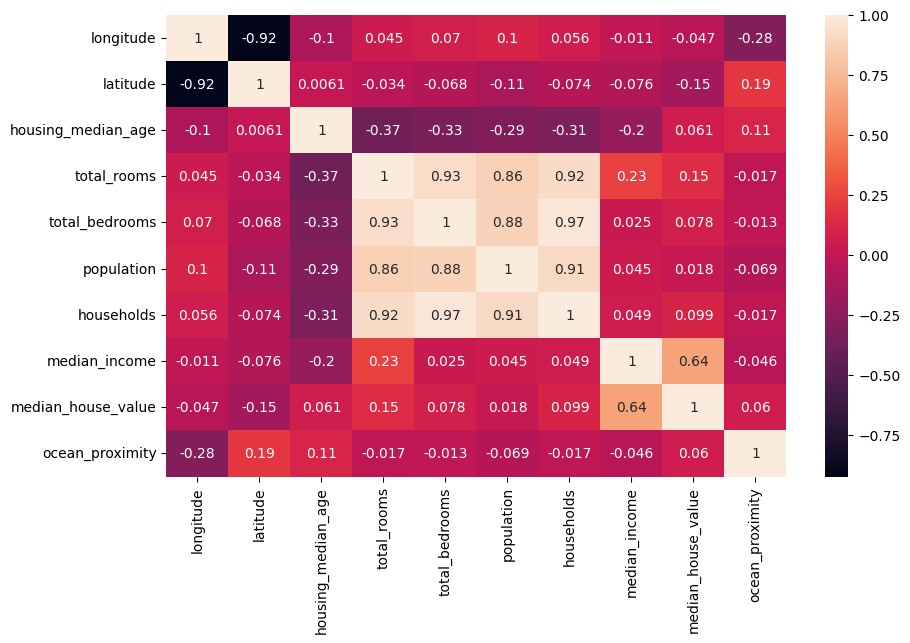

In [52]:
plt.figure(figsize=(10,6))

sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()

In [34]:
data["total_bedrooms"] = data["total_bedrooms"].fillna(data["total_bedrooms"].mean())

In [35]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-1.329808,1.034817,1.011986,-0.796925,-0.977215,-0.978870,-0.979155,2.990995,452600.0,3
1,-1.324823,1.025518,-0.588340,2.051432,1.346353,0.836879,1.660479,2.975718,358500.0,3
2,-1.334794,1.020869,1.892166,-0.528074,-0.832140,-0.826903,-0.846130,2.305580,352100.0,3
3,-1.339780,1.020869,1.892166,-0.616470,-0.725118,-0.772754,-0.736580,1.269368,341300.0,3
4,-1.339780,1.020869,1.892166,-0.454792,-0.618096,-0.766640,-0.632247,0.115947,342200.0,3


In [50]:
scaler = StandardScaler()
data['housing_median_age'] = scaler.fit_transform(data[['housing_median_age']])
data['total_rooms'] = scaler.fit_transform(data[['total_rooms']])   
data['total_bedrooms'] = scaler.fit_transform(data[['total_bedrooms']])
data['population'] = scaler.fit_transform(data[['population']])
data['households'] = scaler.fit_transform(data[['households']])
data['median_income'] = scaler.fit_transform(data[['median_income']])
data['median_house_value'] = scaler.fit_transform(data[['median_house_value']])
data


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-1.329808,1.034817,1.011986,-0.796925,-0.977215,-0.978870,-0.979155,2.990995,2.742648,3
1,-1.324823,1.025518,-0.588340,2.051432,1.346353,0.836879,1.660479,2.975718,1.756648,3
2,-1.334794,1.020869,1.892166,-0.528074,-0.832140,-0.826903,-0.846130,2.305580,1.689588,3
3,-1.339780,1.020869,1.892166,-0.616470,-0.725118,-0.772754,-0.736580,1.269368,1.576423,3
4,-1.339780,1.020869,1.892166,-0.454792,-0.618096,-0.766640,-0.632247,0.115947,1.585853,3
...,...,...,...,...,...,...,...,...,...,...
20635,-0.761432,1.778673,-0.268275,-0.437388,-0.394539,-0.522095,-0.447055,-1.351361,-1.181443,1
20636,-0.821261,1.783322,-0.828389,-0.880741,-0.927271,-0.949175,-1.010455,-0.711713,-1.191921,1
20637,-0.826247,1.755428,-0.908405,-0.167621,-0.130551,-0.380608,-0.178397,-1.261688,-1.032652,1
20638,-0.876104,1.755428,-0.828389,-0.348076,-0.311299,-0.612926,-0.397497,-1.154363,-1.112286,1


In [38]:
x = data[["housing_median_age", "total_rooms", "total_bedrooms", "population", "households", "median_income"]]
y = data["median_house_value"]

In [39]:
 x.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,1.011986,-0.796925,-0.977215,-0.978870,-0.979155,2.990995
1,-0.588340,2.051432,1.346353,0.836879,1.660479,2.975718
2,1.892166,-0.528074,-0.832140,-0.826903,-0.846130,2.305580
3,1.892166,-0.616470,-0.725118,-0.772754,-0.736580,1.269368
4,1.892166,-0.454792,-0.618096,-0.766640,-0.632247,0.115947


In [40]:
x.shape , y.shape

((19569, 6), (19569,))

In [41]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [43]:
X_train.shape, X_test.shape

((15655, 6), (3914, 6))

In [44]:
y_train.shape, y_test.shape

((15655,), (3914,))

In [58]:
######## Liner Regression Model ########
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
### calling the linear regression model ###
model = LinearRegression() 
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
### Checking the coefficients and intercept of the model ###
model.intercept_,model.coef_

(np.float64(191204.17723496063),
 array([ 20507.53894959, -41662.09474241,  30709.88920837, -35756.79672195,
         53427.58235837,  72974.48229611]))

In [57]:
### value prediction using the model ###
predicted_values = model.predict(X_test)
predicted_values

array([ 96868.44063345, 162242.99692454, 237075.99490665, ...,
       154952.43743267, 214287.25240369, 138885.45362863], shape=(3914,))

In [59]:
mean_squared_error(y_test, predicted_values)*100

432803209110.63654

In [60]:
r2_score(y_test, predicted_values)

0.5320136994957277

In [61]:
y_test -predicted_values

2709    -41668.440633
13133   -64442.996925
18028     8224.005093
16330   -24442.959670
5593    -23411.027492
             ...     
6873     62957.688213
8484     -3386.032016
10295    80047.562567
815     -27287.252404
6016    -10185.453629
Name: median_house_value, Length: 3914, dtype: float64

In [62]:
np.sum((y_test -predicted_values)**2)/len(y_test)

np.float64(4328032091.106365)

In [63]:
mean_squared_error(y_test, predicted_values)*100

432803209110.63654

In [64]:
########### Polynomial Regression ###########
from sklearn.preprocessing import PolynomialFeatures


In [65]:
## Polynomial regression with degree 2
poly = PolynomialFeatures(degree=2)

In [ ]:
## Transforming the features into polynomial features
X_poly = poly.fit_transform(X) 
X_poly.shape 

(19569, 55)